In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [4]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [5]:
df = pd.read_excel(fpath + '\\4.0_database_variables.xlsx')

In [6]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'weekday(1=free days)': 'weekday'})

In [7]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [8]:
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [9]:
# Define the start date
start_date = pd.to_datetime('2022-09-21')

In [10]:
# Function to calculate the week of the year from the start date
def calculate_week_of_year(date):
    year_diff = date.year - start_date.year
    start_of_year = pd.to_datetime(f'{date.year}-01-01')
    weeks_from_start = ((date - start_of_year).days // 7) + 1
    return year_diff * 52 + weeks_from_start

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [11]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [12]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday'] = df['weekday'].map({0: 'work days', 1: 'free days'})

# EDA

In [13]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

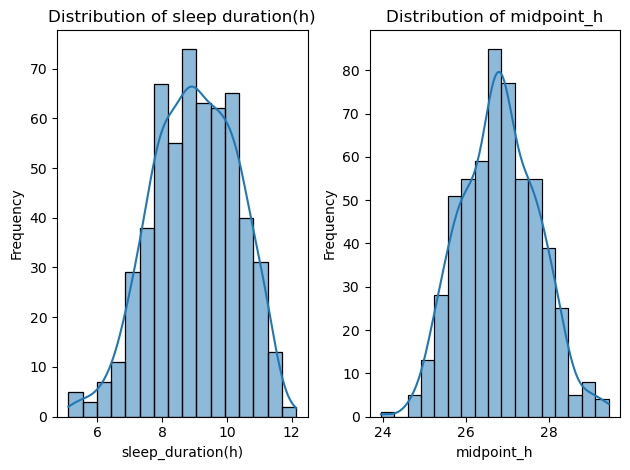

In [14]:
# Distribution 
plt.subplot(1, 2, 1)
sns.histplot(df['sleep_duration(h)'].dropna(), kde=True)
plt.title("Distribution of sleep duration(h)")
plt.xlabel("sleep_duration(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(df['midpoint_h'].dropna(), kde=True)
plt.title("Distribution of midpoint_h")
plt.xlabel("midpoint_h")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

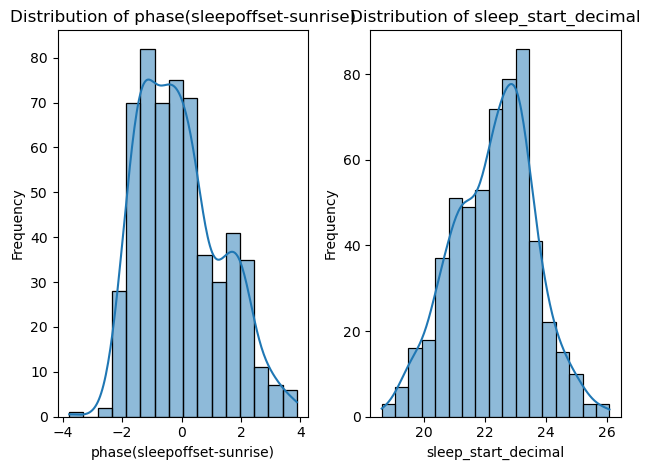

In [15]:
# Distribution 
plt.subplot(1, 2, 1)
sns.histplot(df['phase(sleepoffset-sunrise)'].dropna(), kde=True)
plt.title("Distribution of phase(sleepoffset-sunrise)")
plt.xlabel("phase(sleepoffset-sunrise)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep_start_decimal")
plt.xlabel("sleep_start_decimal")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
# test normality of the data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration(h)'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase(sleepoffset-sunrise)'])

In [17]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midpoint_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [18]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902568788231293, 0.0008572700408180585)"
1,midpoint_h,"(0.9953842221350677, 0.09176026856174113)"
2,sleep_start_decimal,"(0.9933031110054771, 0.012890058203709061)"
3,sleep_end_decimal,"(0.8910493382471318, 1.4676570099459215e-19)"
4,phase(sleepoffset-sunrise),"(0.9644101411394511, 1.8415611196210638e-10)"


In [19]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [20]:
df_grouped_weekday = df.groupby('weekday').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [21]:
df_grouped_location_weekday = df.groupby(['location', 'weekday']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [22]:
# filtered the midpoints by week days
df_workdays = df[df['weekday'] == 'work days']
df_freedays = df[df['weekday'] == 'free days']

In [23]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration(h)'], df[df['location'] == 'UK']['sleep_duration(h)'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'], df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'])


# compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday'] == 'work days']['midpoint_h'], df[df['weekday'] == 'free days']['midpoint_h'])
utest_duration_week = stats.mannwhitneyu(df[df['weekday'] == 'work days']['sleep_duration(h)'], df[df['weekday'] == 'free days']['sleep_duration(h)'])
utest_phase_week = stats.mannwhitneyu(df[df['weekday'] == 'work days']['phase(sleepoffset-sunrise)'], df[df['weekday'] == 'free days']['phase(sleepoffset-sunrise)'])

In [24]:
print('Results for location')
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('Sleep_duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

Results for location
Midpoint_work: TtestResult(statistic=3.2479858746178083, pvalue=0.0012583768691001595, df=408.0)
Midpoint_free: TtestResult(statistic=-0.028649054617328643, pvalue=0.9771818234370077, df=153.0)
Sleep_duration: MannwhitneyuResult(statistic=37319.5, pvalue=0.5273231488217915)
Phase: MannwhitneyuResult(statistic=23106.0, pvalue=6.067805061758257e-16)


In [25]:
print('Results for weekday') 
print('Midpoint:', ttest_midpoint_week)
print('Sleep _duration:', utest_duration_week)
print('Phase:', utest_phase_week)

Results for weekday
Midpoint: TtestResult(statistic=-9.50032089200523, pvalue=5.939401753000896e-20, df=563.0)
Sleep _duration: MannwhitneyuResult(statistic=26278.5, pvalue=0.0015010629524126338)
Phase: MannwhitneyuResult(statistic=19999.5, pvalue=1.037493960895366e-11)


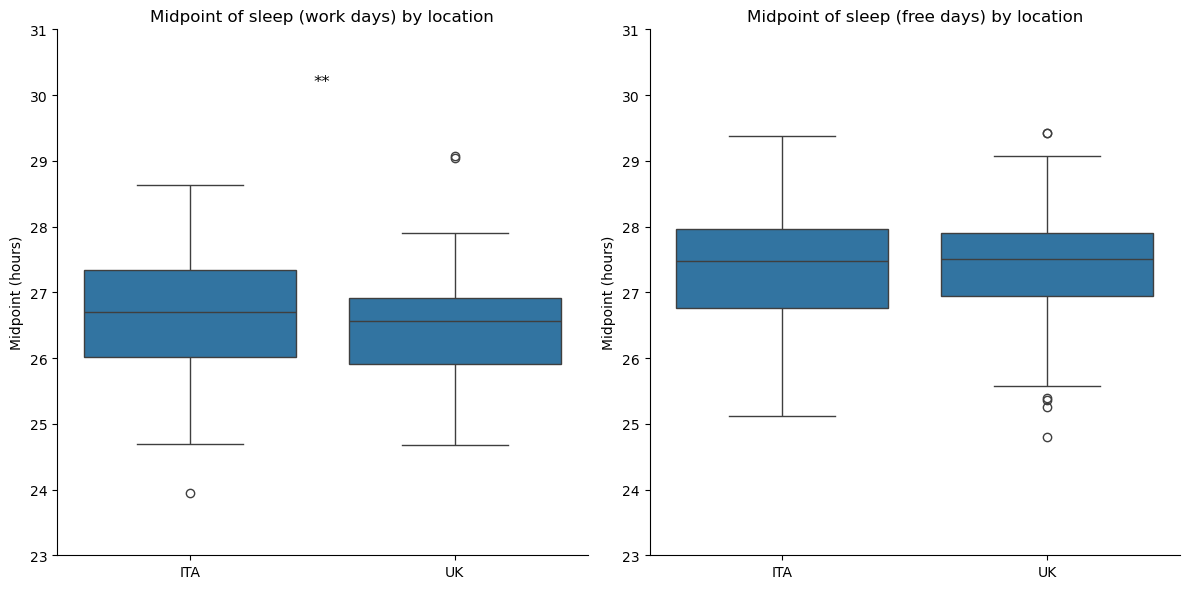

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (hours)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
#add a significance line of ** for the p-value < 0.01
if ttest_midpoint_workdays_loc.pvalue < 0.01:
    ax[0].annotate('**', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 

sns.boxplot(x='location', y='midpoint_h', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (hours)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())
#add a significance line of  for the p-value < 0.05
if ttest_midpoint_workdays_loc.pvalue < 0.01:
    ax[1].annotate('', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

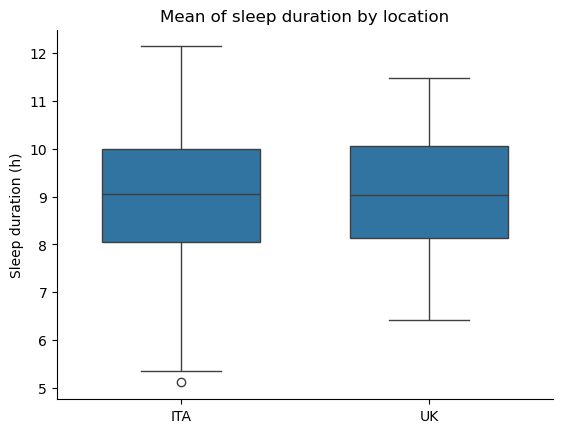

In [27]:
plt.figure()
sns.boxplot(x='location', y='sleep_duration(h)', data=df, gap=0.2)
plt.title('Mean of sleep duration by location')
plt.xlabel('')
plt.ylabel('Sleep duration (h)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.show()

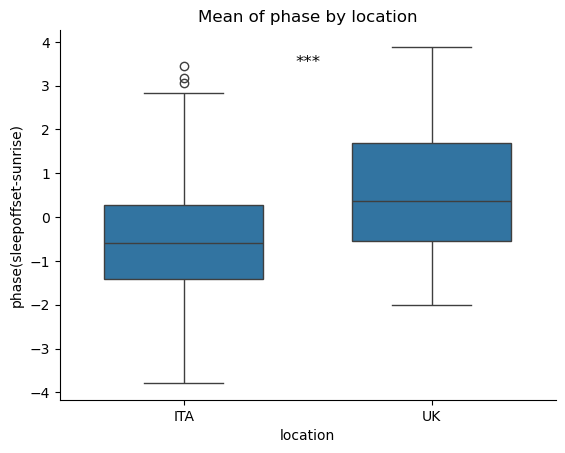

In [28]:
plt.figure()
sns.boxplot(x='location', y='phase(sleepoffset-sunrise)', data=df, gap=0.2)
plt.title('Mean of phase by location')
plt.xlabel('location')
plt.ylabel('phase(sleepoffset-sunrise)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')

#add a significance line 
if utest_phase_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', fontsize=12)
plt.show()

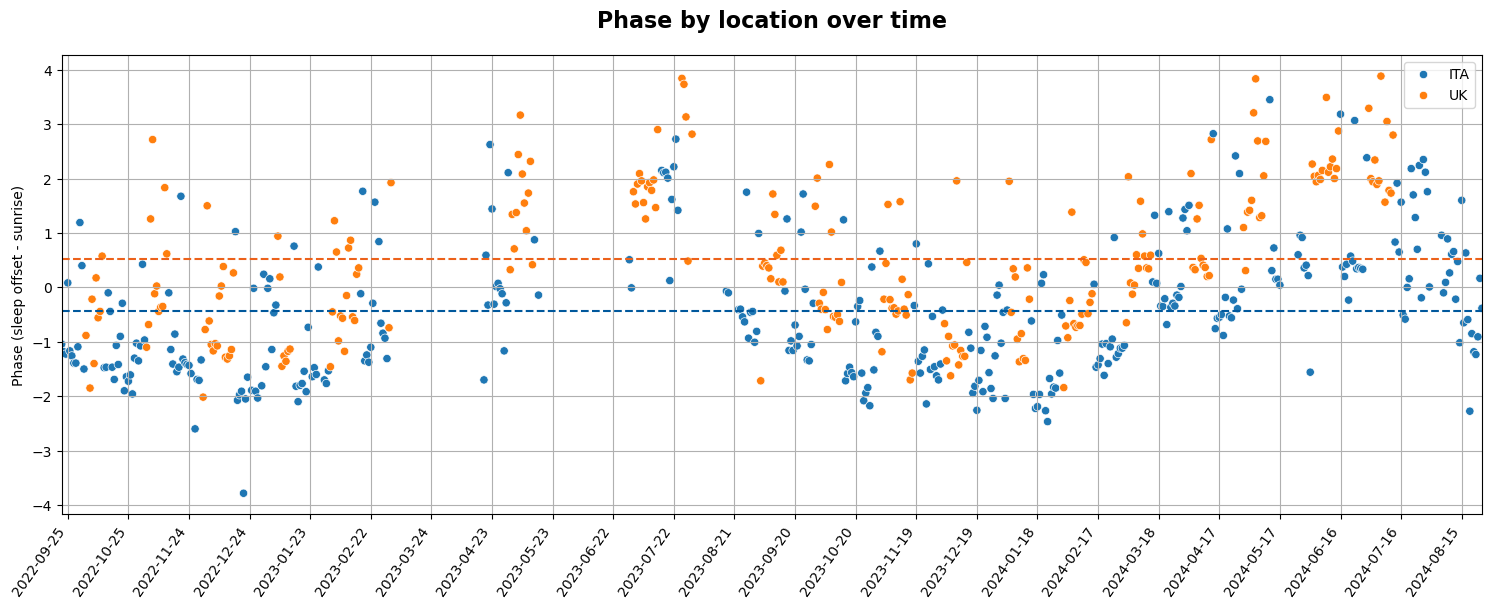

In [29]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase(sleepoffset-sunrise)', hue='location', data=df)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Jetlag_

In [30]:
data_jetlag = df # create a new dataframe with the original data

In [31]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday'])['midpoint_h'].mean().unstack()

In [32]:
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [33]:
# add a column with the location
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [34]:
#save the data to a csv file
weekly_means_jetlag.to_csv(fpath + '\\weekly_means_jetlag.csv')

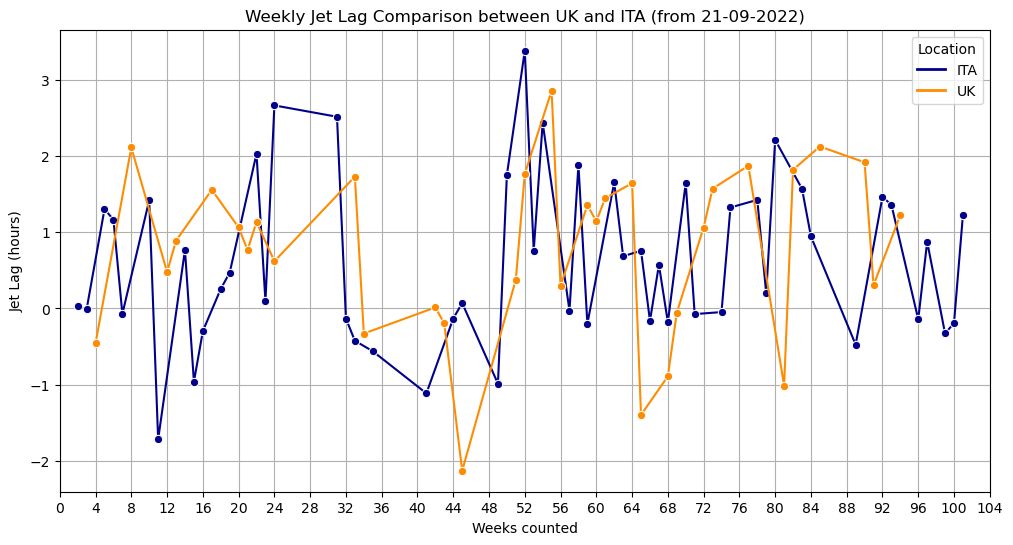

In [35]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_of_year', y='jet lag', hue='location', data=weekly_means_jetlag, marker='o', palette=['darkblue', 'darkorange'])
plt.title('Weekly Jet Lag Comparison between UK and ITA (from 21-09-2022)')
plt.xlabel('Weeks counted')
plt.ylabel('Jet Lag (hours)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange', lw=2)])
plt.grid(True)
plt.xlim(0, 104)
plt.gca().xaxis.set_major_locator(MultipleLocator(4)) 
plt.xticks()
plt.show()

In [36]:
# Remove NaN values before performing the Shapiro-Wilk test
jetlag_no_nan = weekly_means_jetlag['jet lag'].dropna()

In [37]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_no_nan)

In [38]:
shapiro_test_jetlag

ShapiroResult(statistic=0.9886062153387764, pvalue=0.6513971208853703)

In [39]:
# Perform a t-test to compare the jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

print('Results for jet lag:')
print(ttest_jetlag)

Results for jet lag:
TtestResult(statistic=-0.6990671681442698, pvalue=0.48641855739690765, df=85.0)


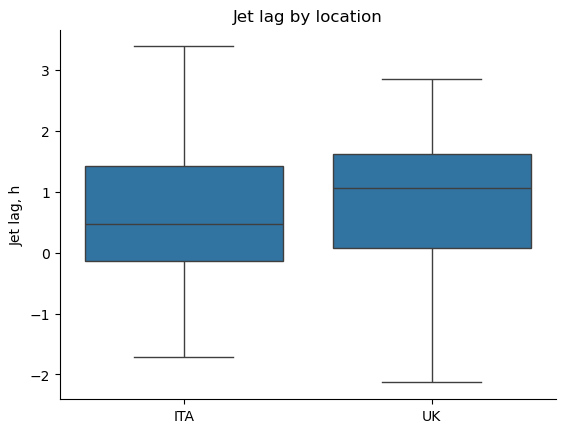

In [40]:
# plot the jet lag
plt.figure()
sns.boxplot(x='location', y='jet lag', data=weekly_means_jetlag)
plt.title('Jet lag by location')
plt.xlabel('')
plt.ylabel('Jet lag, h')

sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.show()

_Seasonal effect_

In [41]:
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})

In [42]:
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [43]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)

def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [44]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_12596\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_12596\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [45]:
df = df.dropna(subset=['sleep_duration'])
df = df.dropna(subset=['phase'])

In [46]:
anova_midpoint_work_season1 = ols('midpoint_h ~ C(season)', data=df_workdays).fit()

In [47]:
anova_midpoint_free_season1 = ols('midpoint_h ~ C(season)', data=df_freedays).fit()

In [48]:
anova_midpoint_work_result_season1 = sm.stats.anova_lm(anova_midpoint_work_season1, typ=3) #fit the ANOVA model and get the results

In [49]:
anova_midpoint_free_result_season1 = sm.stats.anova_lm(anova_midpoint_free_season1, typ=3)

In [50]:
print("\nANOVA_midpoint work Results:")
print(anova_midpoint_work_result_season1)
print("\nANOVA_midpoint free Results:")
print(anova_midpoint_free_result_season1)


ANOVA_midpoint work Results:
                 sum_sq     df              F    PR(>F)
Intercept  79677.117208    1.0  119166.984321  0.000000
C(season)      7.303085    3.0       3.640889  0.012908
Residual     271.458658  406.0            NaN       NaN

ANOVA_midpoint free Results:
                 sum_sq     df             F         PR(>F)
Intercept  33804.524727    1.0  38718.612960  6.452900e-184
C(season)      1.136007    3.0      0.433715   7.291694e-01
Residual     131.835385  151.0           NaN            NaN


In [51]:
# Kruskal-Wallis test 
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration'], df[df['season'] == 'Spring']['sleep_duration'], df[df['season'] == 'Summer']['sleep_duration'], df[df['season'] == 'Autumn']['sleep_duration'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])

# Print the results of the Kruskal-Wallis test
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)


Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5890340956216034, pvalue=0.6618788132777524)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=203.3077922242939, pvalue=8.136011047815583e-44)


In [52]:
# perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df_workdays['midpoint_h'], df_workdays['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0414 0.9852  -0.263 0.3457  False
Autumn Summer    0.312 0.0391  0.0107 0.6133   True
Autumn Winter    0.259 0.0687 -0.0132 0.5311  False
Spring Summer   0.2706  0.139  -0.054 0.5952  False
Spring Winter   0.2176 0.2359 -0.0801 0.5153  False
Summer Winter   -0.053 0.9668 -0.3476 0.2416  False
---------------------------------------------------


In [53]:
# perform a Tukey HSD test to compare the means
tukey_results_season2 = pairwise_tukeyhsd(df_freedays['midpoint_h'], df_freedays['season'])
print(tukey_results_season2)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0419 0.9975 -0.5247 0.6085  False
Autumn Summer  -0.2041 0.7809 -0.7654 0.3572  False
Autumn Winter  -0.0569 0.9913 -0.5632 0.4494  False
Spring Summer   -0.246 0.7235 -0.8577 0.3658  False
Spring Winter  -0.0988 0.9682 -0.6605 0.4628  False
Summer Winter   0.1472 0.9019 -0.4092 0.7035  False
---------------------------------------------------


In [54]:
# Perform a Tukey HSD test to compare the means 
tukey_results_season3 = pairwise_tukeyhsd(df['sleep_duration'], df['season'])
print(tukey_results_season3)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0187 0.9994 -0.3899 0.4273  False
Autumn Summer  -0.1612 0.7337 -0.5657 0.2433  False
Autumn Winter  -0.1025  0.888 -0.4677 0.2628  False
Spring Summer  -0.1799 0.7139 -0.6171 0.2573  False
Spring Winter  -0.1211 0.8644 -0.5223   0.28  False
Summer Winter   0.0588 0.9811 -0.3383 0.4558  False
---------------------------------------------------


In [55]:
# Perform a Tukey HSD test to compare the means
tukey_results_season4 = pairwise_tukeyhsd(df['phase'], df['season'])
print(tukey_results_season4)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.2441    0.0  0.8949  1.5933   True
Autumn Summer   1.7125    0.0  1.3668  2.0583   True
Autumn Winter  -0.2876 0.0834 -0.5997  0.0246  False
Spring Summer   0.4685 0.0071  0.0948  0.8421   True
Spring Winter  -1.5316    0.0 -1.8745 -1.1888   True
Summer Winter  -2.0001    0.0 -2.3394 -1.6608   True
----------------------------------------------------


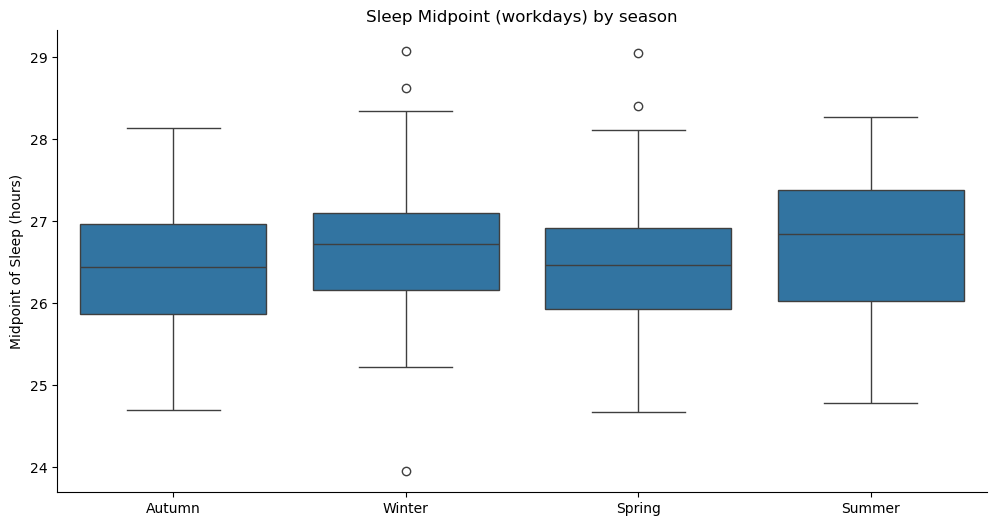

In [56]:
# Sleep Midpoint (work) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h', data=df_workdays)
plt.title('Sleep Midpoint (workdays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of Sleep (hours)')
plt.xlabel('')
sns.despine()
plt.grid(False)
#bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

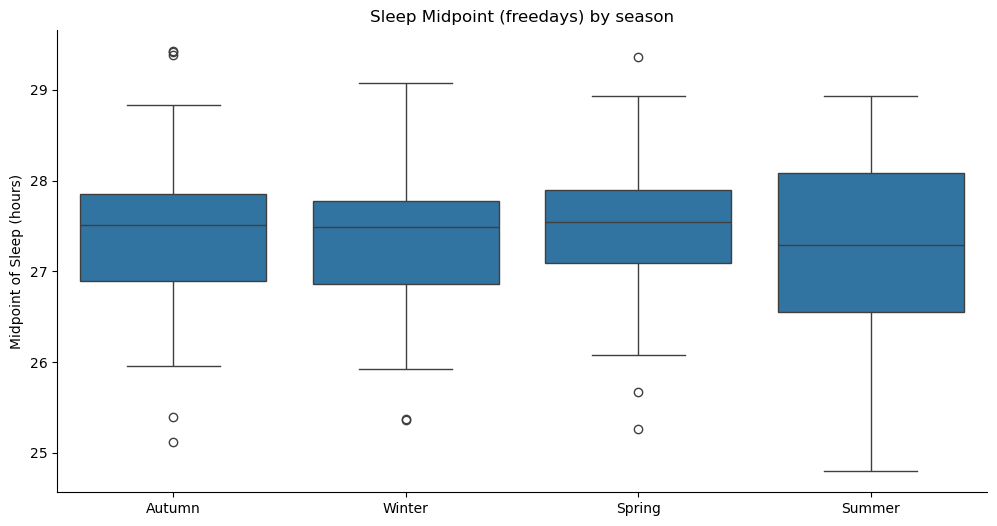

In [57]:
# Sleep Midpoint (free) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h', data=df_freedays)
plt.title('Sleep Midpoint (freedays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of Sleep (hours)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

<Figure size 1200x600 with 0 Axes>

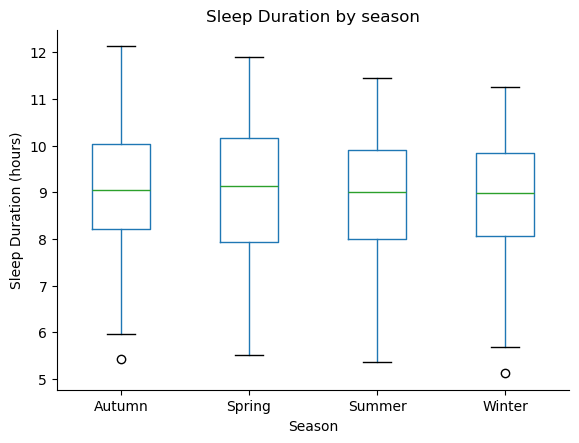

In [58]:
# Sleep Duration by season
plt.figure(figsize=(12, 6))
df.boxplot(column='sleep_duration', by='season', grid=False)
plt.title('Sleep Duration by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep Duration (hours)')
plt.xlabel('Season')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

<Figure size 1200x600 with 0 Axes>

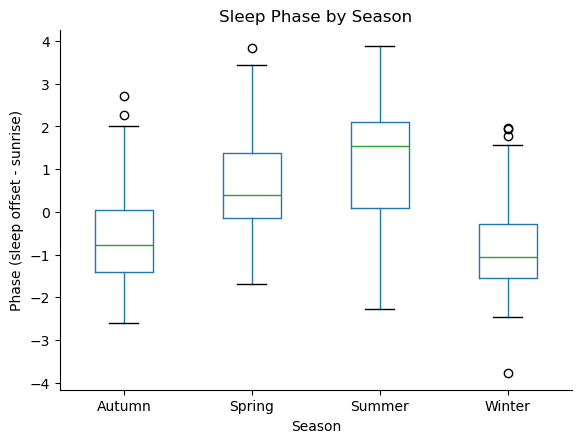

In [59]:
# Sleep Phase by season
plt.figure(figsize=(12, 6))
df.boxplot(column='phase', by='season', grid=False)
plt.title('Sleep Phase by Season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('Season')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

_Phase by location and time_

In [60]:
import statsmodels.formula.api as smf

In [61]:
data_phase = df.dropna(subset=['phase', 'location', 'date'])

In [62]:
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1})

In [63]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [64]:
glm_model_phase_numeric = smf.glm(
    formula="phase ~ location + date_numeric",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [65]:
# Fit of the model
glm_results_phase_numeric = glm_model_phase_numeric.fit()

In [66]:
# Output the summary of the model
glm_results_phase_numeric_summary = glm_results_phase_numeric.summary()
glm_results_phase_numeric_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  565
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.4737
Method:                          IRLS   Log-Likelihood:                -909.75
Date:                Thu, 31 Oct 2024   Deviance:                       828.24
Time:                        11:28:11   Pearson chi2:                     828.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2503
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2292      0.112    -10.993      0.000      -1.448      -1.010
location         0.9844      0.104      9.467      0.000       0.781       1.188
date_numeric     0.0021      0.000      8.764      0.000       0.002       0.003
================================================================================
"""

_Midpoint by location and week day_

In [67]:
model_1 = ols('midpoint_h ~ C(location) * C(weekday)', data=df).fit() # C() is used to indicate categorical variables

In [68]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [69]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                              sum_sq     df             F        PR(>F)
Intercept               71090.857907    1.0  98545.463270  0.000000e+00
C(location)                 0.000713    1.0      0.000989  9.749257e-01
C(weekday)                 29.125550    1.0     40.373558  4.342691e-10
C(location):C(weekday)      1.959224    1.0      2.715858  9.991545e-02
Residual                  404.706315  561.0           NaN           NaN


In [70]:
# coefficients of the model
weights = model_1.params / model_1.params.abs().sum()
weights

Intercept                                    0.967166
C(location)[T.UK]                            0.000156
C(weekday)[T.work days]                     -0.023129
C(location)[T.UK]:C(weekday)[T.work days]   -0.009550
dtype: float64

In [71]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['midpoint_h'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [72]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.6542    0.0 -0.9195 -0.3889   True
ITA_free days  UK_free days   0.0044    1.0 -0.3565  0.3653  False
ITA_free days  UK_work days  -0.9199    0.0 -1.2002 -0.6395   True
ITA_work days  UK_free days   0.6586    0.0  0.3427  0.9745   True
ITA_work days  UK_work days  -0.2657 0.0102 -0.4851 -0.0463   True
 UK_free days  UK_work days  -0.9243    0.0 -1.2529 -0.5957   True
------------------------------------------------------------------


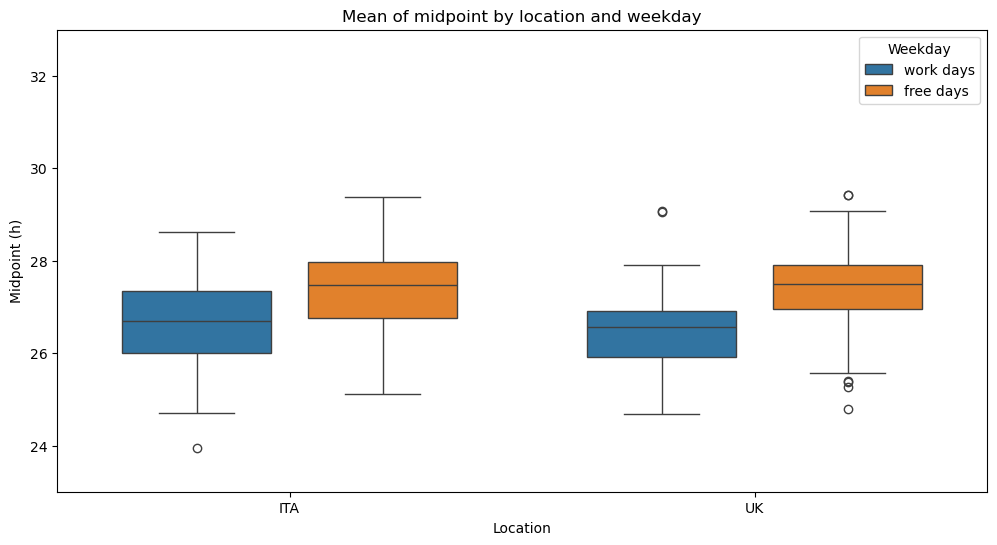

In [73]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h', hue='weekday', data=df, gap=0.2)
plt.title('Mean of midpoint by location and weekday')
plt.xlabel('Location')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
plt.legend(title='Weekday')
plt.show()

_Sleep duration by location and week day_

In [74]:
data_sleep_duration = df.dropna(subset=['sleep_duration', 'location', 'weekday'])

In [75]:
glm_model_sleep_duration = smf.glm(
    formula="sleep_duration ~ location + weekday",
    data=data_sleep_duration,
    family=sm.families.Gaussian()
)

In [76]:
# Fit of the model
glm_results_sleep_duration = glm_model_sleep_duration.fit()

In [77]:
# Output the summary of the model (ita and free days as baseline)
glm_results_sleep_duration_summary = glm_results_sleep_duration.summary()
glm_results_sleep_duration_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:         sleep_duration   No. Observations:                  565
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.6418
Method:                          IRLS   Log-Likelihood:                -940.25
Date:                Thu, 31 Oct 2024   Deviance:                       922.68
Time:                        11:28:11   Pearson chi2:                     923.
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01776
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                9.2238      0.111     82.841      0.000       9.006       9.442
location[T.UK]           0.1196      0.110      1.090      0.276      -0.096       0.335
weekday[T.work days]    -0.3643      0.121     -3.014      0.003      -0.601      -0.127
========================================================================================
"""

In [78]:
# post-hoc test 
posthoc_sleep_duration = pairwise_tukeyhsd(
    endog=df['sleep_duration'],  
    groups=data_sleep_duration['location'].astype(str) + '_' + data_sleep_duration['weekday'].astype(str),  
    alpha=0.05  
)

In [79]:
print(posthoc_sleep_duration)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
ITA_free days ITA_work days  -0.3715 0.0802 -0.7721  0.029  False
ITA_free days  UK_free days   0.1062 0.9586 -0.4387 0.6511  False
ITA_free days  UK_work days   -0.247 0.4361 -0.6703 0.1763  False
ITA_work days  UK_free days   0.4777 0.0495  0.0007 0.9547   True
ITA_work days  UK_work days   0.1245 0.7673 -0.2067 0.4558  False
 UK_free days  UK_work days  -0.3532 0.2585 -0.8494  0.143  False
-----------------------------------------------------------------


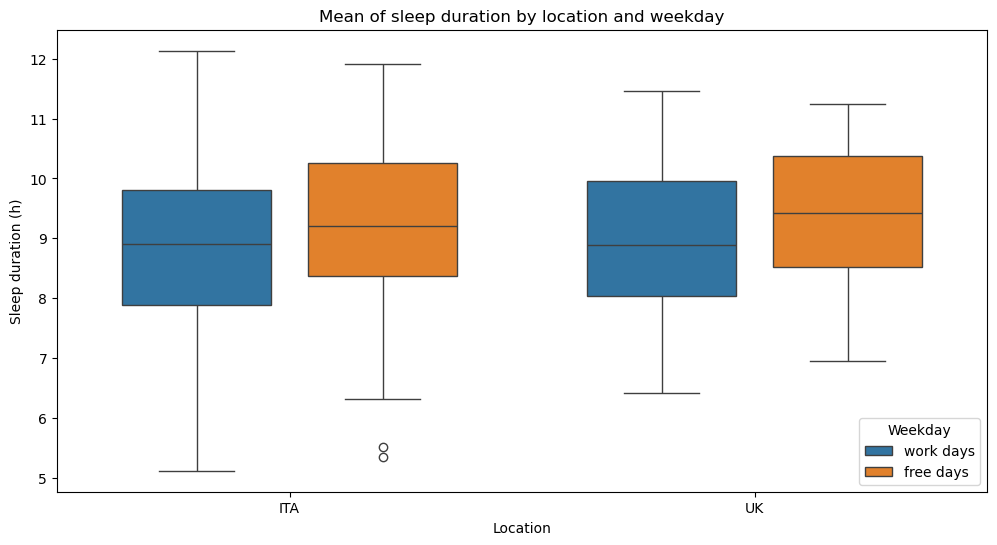

In [80]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='sleep_duration', hue='weekday', data=data_sleep_duration, gap=0.2)
plt.title('Mean of sleep duration by location and weekday')
plt.xlabel('Location')
plt.ylim()
plt.ylabel('Sleep duration (h)')
plt.legend(title='Weekday')
plt.show()

_Phase by location and week day_

In [81]:
data_phase2 = df.dropna(subset=['phase', 'location', 'weekday'])

In [82]:
glm_model_phase2 = smf.glm(
    formula="phase ~ location + weekday",
    data=data_phase2,
    family=sm.families.Gaussian()
)

In [83]:
# Fit of the model
glm_results_phase2 = glm_model_phase2.fit()

In [84]:
# Output the summary of the model (ita and free days as baseline)
glm_results_phase2_summary = glm_results_phase2.summary()
glm_results_phase2_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  565
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.5033
Method:                          IRLS   Log-Likelihood:                -915.35
Date:                Thu, 31 Oct 2024   Deviance:                       844.83
Time:                        11:28:12   Pearson chi2:                     845.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2312
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2238      0.107      2.100      0.036       0.015       0.433
location[T.UK]           0.9849      0.105      9.378      0.000       0.779       1.191
weekday[T.work days]    -0.9270      0.116     -8.016      0.000      -1.154      -0.700
========================================================================================
"""

In [85]:
# post-hoc test 
posthoc_3 = pairwise_tukeyhsd(
    endog=data_phase2['phase'],  
    groups=data_phase2['location'].astype(str) + '_' + data_phase2['weekday'].astype(str),  
    alpha=0.05  
)

In [86]:
print(posthoc_3)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.9474    0.0 -1.3307 -0.5641   True
ITA_free days  UK_free days   0.9471    0.0  0.4257  1.4686   True
ITA_free days  UK_work days   0.0515 0.9878 -0.3535  0.4566  False
ITA_work days  UK_free days   1.8945    0.0  1.4381  2.3509   True
ITA_work days  UK_work days   0.9989    0.0  0.6819  1.3159   True
 UK_free days  UK_work days  -0.8956    0.0 -1.3704 -0.4208   True
------------------------------------------------------------------


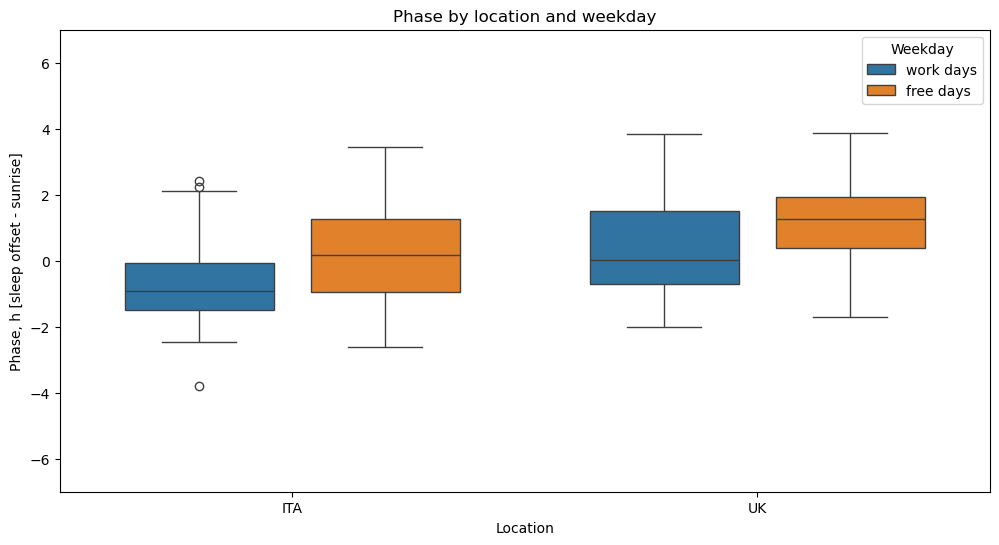

In [87]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday', data=data_phase2, gap=0.2)
plt.title('Phase by location and weekday')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend(title='Weekday')

plt.show()

_Photoperiod and sleep-wake pattern_

In [88]:
# Selecting relevant columns for correlation analysis
sleep_wake_vars = ["sleep_duration", "midpoint_h"]
photoperiod_vars = ["photoperiod (h, UK)", "photoperiod (h, ITA)"]

In [89]:
# Calculating the correlation matrix between photoperiod and sleep-wake variables
correlation_matrix = data_sleep_duration[sleep_wake_vars + photoperiod_vars].corr()

In [90]:
# Displaying the correlation matrix
correlation_matrix

,sleep_duration,midpoint_h,"photoperiod (h, UK)","photoperiod (h, ITA)"
sleep_duration,1.000000,-0.404714,-0.022371,-0.022535
midpoint_h,-0.404714,1.000000,0.006159,0.006728
"photoperiod (h, UK)",-0.022371,0.006159,1.000000,0.999973
"photoperiod (h, ITA)",-0.022535,0.006728,0.999973,1.000000


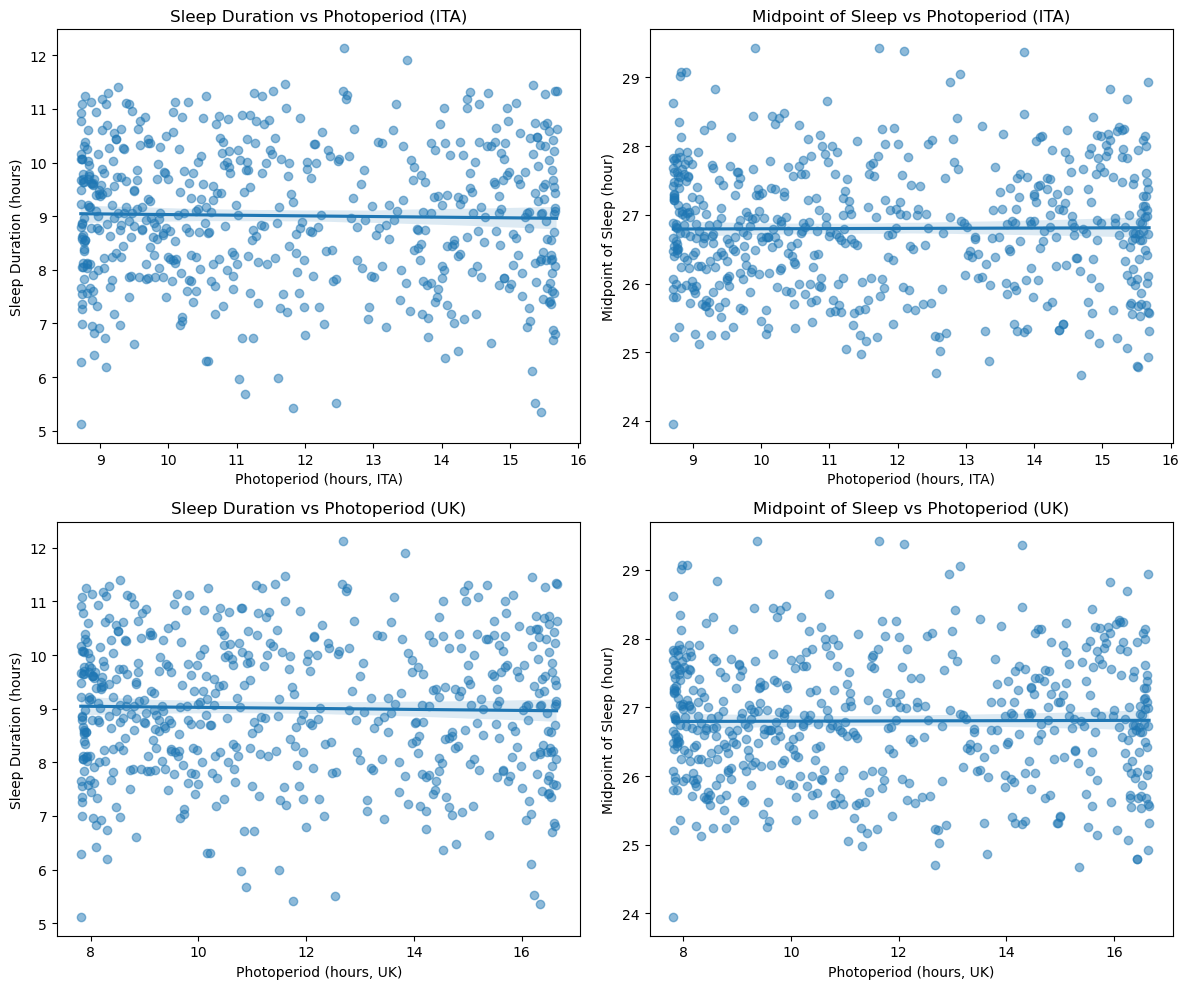

In [91]:
plt.figure(figsize=(12, 10))

# Plot 1: Photoperiod (ITA) vs Sleep Duration
plt.subplot(2, 2, 1)
sns.regplot(x="photoperiod (h, ITA)", y="sleep_duration", data=data_sleep_duration, scatter_kws={'alpha':0.5})
plt.title("Sleep Duration vs Photoperiod (ITA)")
plt.xlabel("Photoperiod (hours, ITA)")
plt.ylabel("Sleep Duration (hours)")

# Plot 2: Photoperiod (ITA) vs Midpoint of Sleep
plt.subplot(2, 2, 2)
sns.regplot(x="photoperiod (h, ITA)", y="midpoint_h", data=data_sleep_duration, scatter_kws={'alpha':0.5})
plt.title("Midpoint of Sleep vs Photoperiod (ITA)")
plt.xlabel("Photoperiod (hours, ITA)")
plt.ylabel("Midpoint of Sleep (hour)")

# Plot 3: Photoperiod (UK) vs Sleep Duration
plt.subplot(2, 2, 3)
sns.regplot(x="photoperiod (h, UK)", y="sleep_duration", data=data_sleep_duration, scatter_kws={'alpha':0.5})
plt.title("Sleep Duration vs Photoperiod (UK)")
plt.xlabel("Photoperiod (hours, UK)")
plt.ylabel("Sleep Duration (hours)")

# Plot 4: Photoperiod (UK) vs Midpoint of Sleep
plt.subplot(2, 2, 4)
sns.regplot(x="photoperiod (h, UK)", y="midpoint_h", data=data_sleep_duration, scatter_kws={'alpha':0.5})
plt.title("Midpoint of Sleep vs Photoperiod (UK)")
plt.xlabel("Photoperiod (hours, UK)")
plt.ylabel("Midpoint of Sleep (hour)")

# Display the plots
plt.tight_layout()
plt.show()


In [92]:
# Load the datasets
weekly_values = pd.read_csv(fpath + '\\weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag

In [93]:
# Split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [94]:
# Convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [95]:
# Merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

print(merged_data.head())

   week_of_year                Date_Range        IS        IV        RA  \
0            41  2022-10-12 to 2022-10-18  0.593843  0.089441  0.945319   
1            42  2022-10-19 to 2022-10-25  0.592888  0.086393  0.934961   
2            43  2022-10-26 to 2022-11-01  0.615197  0.086685  0.958284   
3            44  2022-11-02 to 2022-11-08  0.552785  0.081076  0.911548   
4            45  2022-11-09 to 2022-11-15  0.555176  0.070588  0.944386   

  Start_Date   End_Date  free days  work days   jet lag location  
0 2022-10-12 2022-10-18  26.491667  27.608333 -1.116667      ITA  
1 2022-10-19 2022-10-25  26.037500  26.024167  0.013333       UK  
2 2022-10-26 2022-11-01  25.975000  26.172500 -0.197500       UK  
3 2022-11-02 2022-11-08  27.697917  27.830833 -0.132917      ITA  
4 2022-11-09 2022-11-15  27.933333  27.862500  0.070833      ITA  


In [96]:
# Summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       51.0  0.078998  0.021793  0.024172  0.067675  0.081076  0.090757   
UK        36.0  0.088097  0.020323  0.040270  0.075134  0.086539  0.099973   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  51.0  0.523448  ...  0.604193  0.647358  50.0  0.934366   
UK        0.130562  36.0  0.537676  ...  0.614306  0.645810  36.0  0.917165   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.070674  0.480668  0.932392  0.941753  0.949313  1.097278  
UK        0.091460  0.480668  0.922486  0.940388  0.947696  0.964346  

[2 rows x 24 columns]

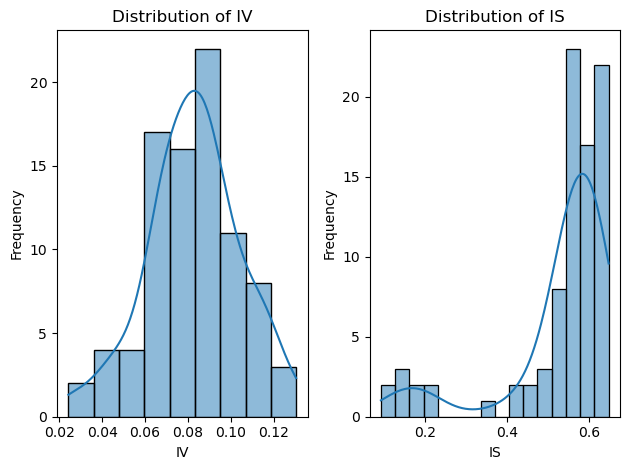

In [97]:
# Distribution 
plt.subplot(1, 2, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title("Distribution of IV")
plt.xlabel("IV")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

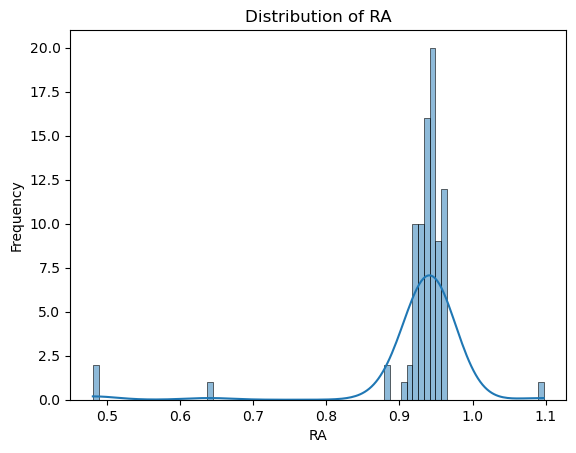

In [98]:
#plot the RA
plt.figure()
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title("Distribution of RA")
plt.xlabel("RA")
plt.ylabel("Frequency")
plt.show()

In [99]:
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [100]:
print("\nT-test results for IV by Location:", iv_ttest)
print("U-test results for IS by Location:", is_ttest)
print("T-test results for RA by Location:", ra_ttest)


T-test results for IV by Location: TtestResult(statistic=-1.9715074953727594, pvalue=0.05191870528148813, df=85.0)
U-test results for IS by Location: MannwhitneyuResult(statistic=897.0, pvalue=0.8597536798194605)
T-test results for RA by Location: TtestResult(statistic=0.9837280409171583, pvalue=0.32807424964869647, df=84.0)


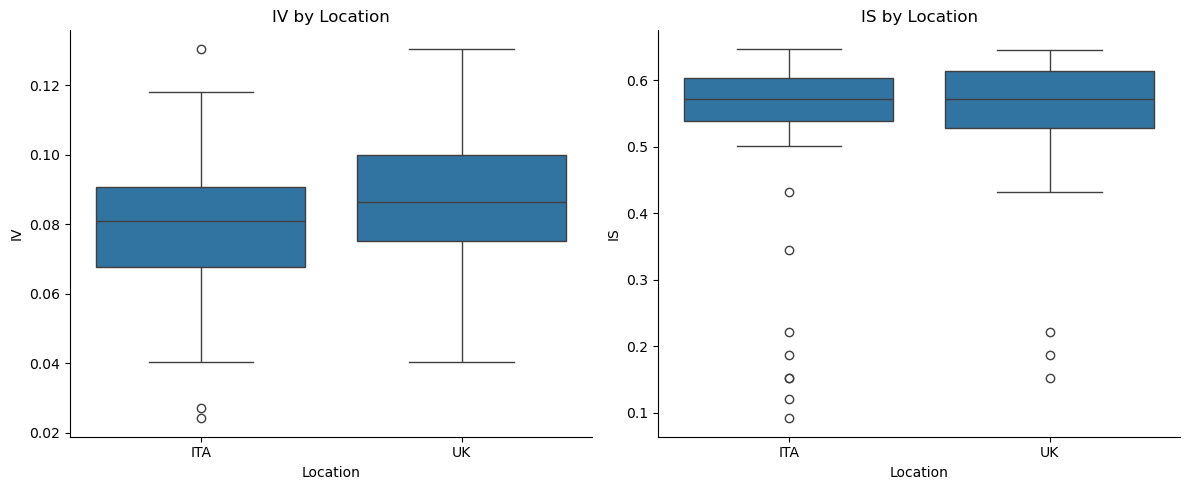

In [101]:
plt.figure(figsize=(12, 5))

# IV by Location
plt.subplot(1, 2, 1)
sns.boxplot(x="location", y="IV", data=merged_data)
plt.title("IV by Location")
plt.xlabel("Location")
plt.ylabel("IV")

# IS by Location
plt.subplot(1, 2, 2)
sns.boxplot(x="location", y="IS", data=merged_data)
plt.title("IS by Location")
plt.xlabel("Location")
plt.ylabel("IS")

sns.despine()
plt.tight_layout()
plt.show()

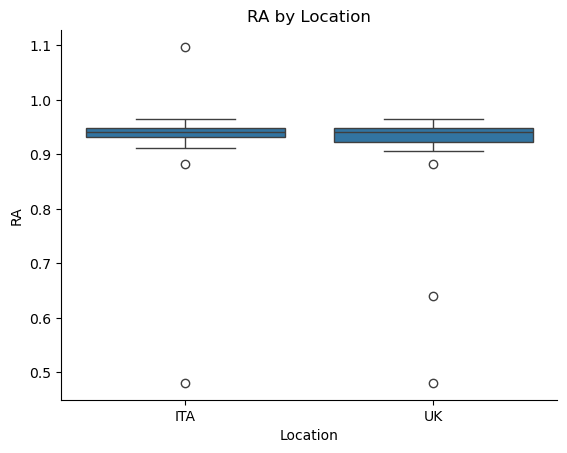

In [102]:
plt.figure()   
# RA by Location
sns.boxplot(x="location", y="RA", data=merged_data)
plt.title("RA by Location")
plt.xlabel("Location")
plt.ylabel("RA")

sns.despine()

plt.show()